In [1]:
pip install numpy matplotlib tensorflow torch


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

In [3]:
X = np.array([[0,0], [0,1], [1,0], [1,1]], dtype=float)

y = np.array([[0], [1], [1], [0]], dtype=float)

In [4]:

model = Sequential([Input(shape=(2,)), Dense(8, activation='tanh'), Dense(1, activation='sigmoid')])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [5]:
history = model.fit(X, y, epochs=200, verbose=0)

In [6]:
pred = model.predict(X)
print("Keras Predictions:")
print(np.round(pred))

loss, acc = model.evaluate(X, y, verbose=0)
print("Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Keras Predictions:
[[0.]
 [1.]
 [1.]
 [0.]]
Accuracy: 1.0


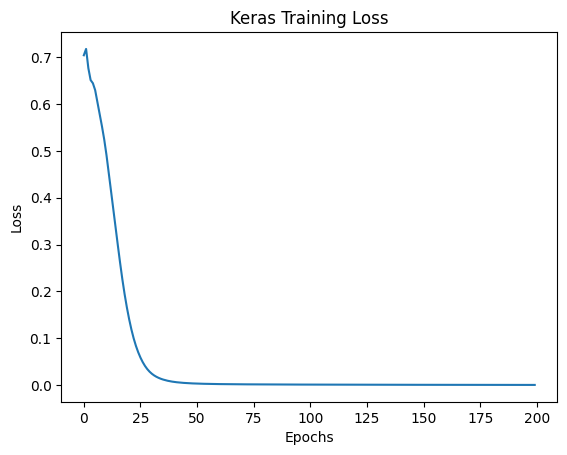

In [7]:
plt.plot(history.history['loss'])
plt.title("Keras Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


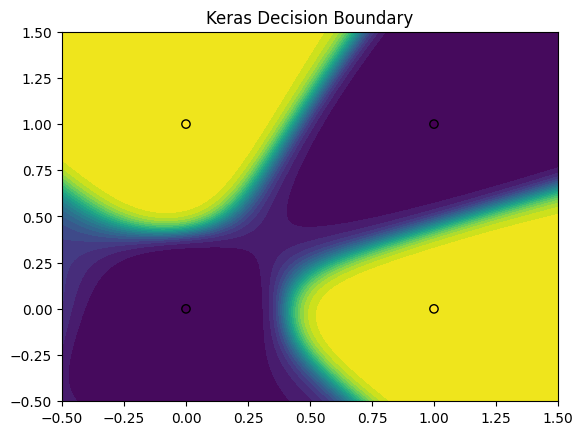

In [8]:
xx, yy = np.meshgrid(np.linspace(-0.5,1.5,200),
                     np.linspace(-0.5,1.5,200))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = model.predict(grid).reshape(xx.shape)

plt.contourf(xx, yy, Z, levels=20)
plt.scatter(X[:,0], X[:,1], c=y.flatten(), edgecolors='k')
plt.title("Keras Decision Boundary")
plt.show()

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

In [10]:
X = torch.tensor([[0,0],[0,1],[1,0],[1,1]], dtype=torch.float32)
y = torch.tensor([[0],[1],[1],[0]], dtype=torch.float32)


In [11]:
class XORNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 8)
        self.fc2 = nn.Linear(8, 1)

    def forward(self, x):
        x = torch.tanh(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x

model = XORNet()

In [12]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.1)


In [13]:
losses = []
for epoch in range(200):
    optimizer.zero_grad()
    output = model(X)
    loss = criterion(output, y)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

In [14]:
with torch.no_grad():
    pred = model(X)
    print("PyTorch Predictions:")
    print(torch.round(pred))
    acc = ((torch.round(pred) == y).float().mean())
    print("Accuracy:", acc.item())


PyTorch Predictions:
tensor([[0.],
        [1.],
        [1.],
        [0.]])
Accuracy: 1.0


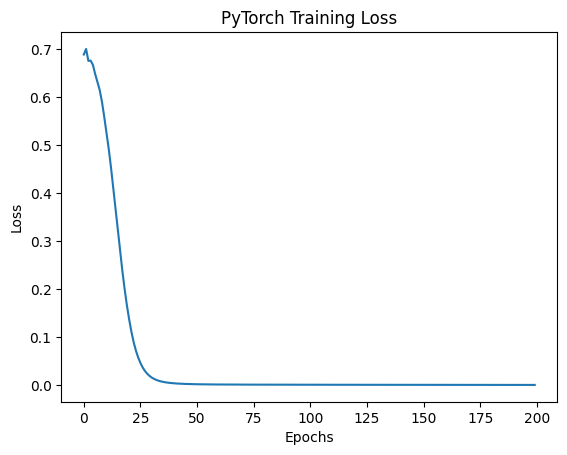

In [15]:
plt.plot(losses)
plt.title("PyTorch Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

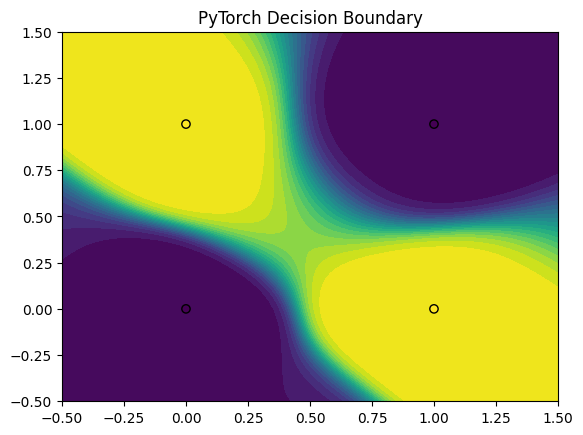

In [16]:
xx, yy = np.meshgrid(np.linspace(-0.5,1.5,200),
                     np.linspace(-0.5,1.5,200))
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

with torch.no_grad():
    Z = model(grid).numpy().reshape(xx.shape)

plt.contourf(xx, yy, Z, levels=20)
plt.scatter(X[:,0], X[:,1], c=y.numpy().flatten(), edgecolors='k')
plt.title("PyTorch Decision Boundary")
plt.show()

In [17]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [18]:
X = tf.constant([[0.,0.], [0.,1.], [1.,0.], [1.,1.]])
y = tf.constant([[0.], [1.], [1.], [0.]])

In [19]:
W1 = tf.Variable(tf.random.normal([2,8]))
b1 = tf.Variable(tf.zeros([8]))
W2 = tf.Variable(tf.random.normal([8,1]))
b2 = tf.Variable(tf.zeros([1]))

optimizer = tf.optimizers.Adam(learning_rate=0.1)
loss_fn = tf.losses.BinaryCrossentropy()

In [20]:
losses = []
for epoch in range(200):
    with tf.GradientTape() as tape:
        h = tf.tanh(tf.matmul(X, W1) + b1)
        out = tf.sigmoid(tf.matmul(h, W2) + b2)
        loss = loss_fn(y, out)

    grads = tape.gradient(loss, [W1, b1, W2, b2])
    optimizer.apply_gradients(zip(grads, [W1, b1, W2, b2]))
    losses.append(loss.numpy())

In [21]:
pred = tf.round(out)
print("TensorFlow Predictions:")
print(pred.numpy())
accuracy = tf.reduce_mean(tf.cast(pred == y, tf.float32))
print("Accuracy:", accuracy.numpy())

TensorFlow Predictions:
[[0.]
 [1.]
 [1.]
 [0.]]
Accuracy: 1.0


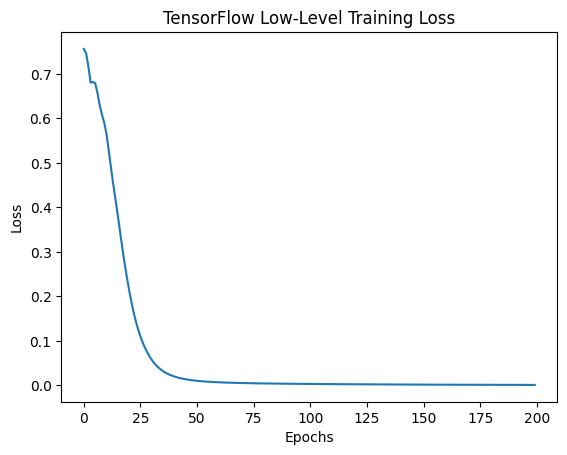

In [22]:
plt.plot(losses)
plt.title("TensorFlow Low-Level Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

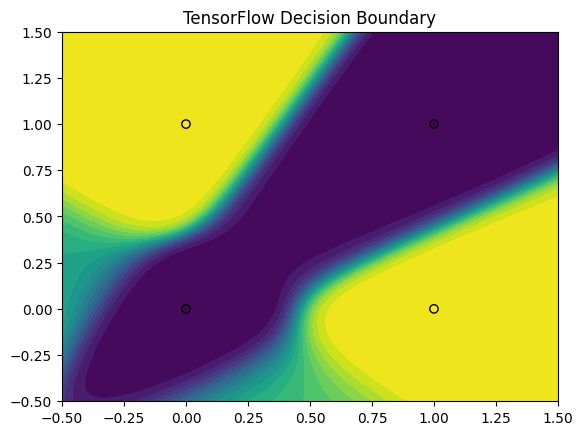

In [23]:
xx, yy = np.meshgrid(np.linspace(-0.5,1.5,200),
                     np.linspace(-0.5,1.5,200))
grid = tf.constant(np.c_[xx.ravel(), yy.ravel()], dtype=tf.float32)

h = tf.tanh(tf.matmul(grid, W1) + b1)
Z = tf.sigmoid(tf.matmul(h, W2) + b2)
Z = Z.numpy().reshape(xx.shape)

plt.contourf(xx, yy, Z, levels=20)
plt.scatter(X[:,0], X[:,1], c=y.numpy().flatten(), edgecolors='k')
plt.title("TensorFlow Decision Boundary")
plt.show()